# Detección de Huecos en Carreteras — Pothole Detection

**Dataset:** `taroii/pothole-detection`  
**Modelo:** InceptionV3 con Transfer Learning  
**Tarea:** Clasificación binaria: `pothole` vs `no pothole`

Este notebook está organizado para trabajar con varios archivos del proyecto en la carpeta `src/`.


## 1. Imports y reproducibilidad

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

# PARCHE RAIZ: BaseComm.open ? guard para evitar recursion infinita si la celda
# se re-ejecuta sin reiniciar el kernel (_orig_bc_open no debe apuntar a _safe_bc_open).
try:
    import comm.base_comm as _bc
    if not getattr(_bc.BaseComm, '_already_patched', False):
        _orig_bc_open = _bc.BaseComm.open

        def _safe_bc_open(self, data=None, metadata=None, buffers=None):
            try:
                _orig_bc_open(self, data=data, metadata=metadata, buffers=buffers)
            except LookupError:
                self._closed = False

        _bc.BaseComm.open = _safe_bc_open
        _bc.BaseComm._already_patched = True
        print('BaseComm.open parcheado ? widgets seguros en hilos')
    else:
        print('BaseComm.open ya parcheado ? sin cambios')
except Exception as _e:
    print(f'Advertencia parche BaseComm: {_e}')

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_DISABLE_XET"] = "1"

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.data_loaders import (
    load_pothole_dataset,
    create_dataloaders,
    plot_class_distribution,
    show_samples_by_class,
    image_dimension_report,
    pixel_statistics_report,
)
from src.models import build_pothole_inception, unfreeze_last_layers, count_trainable_parameters
from src.model_training import train_model, evaluate, classification_metrics
from src.utils import plot_training_curves, plot_confusion_matrix, show_predictions
from src.xai import attach_hooks, run_forward, run_backward, compute_gradcam, resize_cam, tensor_to_uint8, overlay_cam

try:
    import huggingface_hub.file_download as _hf_fd
    _hf_fd.is_xet_available = lambda: False
    print('is_xet_available parcheado ? Xet Storage desactivado')
except Exception as _e:
    print(f'Advertencia parche Xet: {_e}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Semillas fijadas: {SEED} | CUDA deterministic: {torch.cuda.is_available()}")
print(f"Usando: {DEVICE.type.upper()}")


## 2. Carga del dataset

Se carga el dataset de Hugging Face y se detectan automáticamente la columna de imagen, la columna de etiqueta y los nombres de las clases.


In [2]:
DATASET_NAME = "taroii/pothole-detection"

info = load_pothole_dataset(DATASET_NAME)
ds = info.dataset

print("Splits disponibles:", list(ds.keys()))
print("Columna imagen:", info.image_key)
print("Columna etiqueta:", info.label_key)
print("Clases:", info.class_names)
print("Número de clases:", info.num_classes)

for split in ds.keys():
    print(f"{split}: {len(ds[split])} imágenes")


Resolving data files:   0%|          | 0/200 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Splits disponibles: ['train', 'validation', 'test']
Columna imagen: image
Columna etiqueta: label
Clases: ['no pothole', 'pothole']
Número de clases: 2
train: 200 imágenes
validation: 165 imágenes
test: 72 imágenes


## 3. EDA — Análisis exploratorio de datos

Esta sección conserva la lógica del EDA del notebook original: distribución de clases por split, ejemplos visuales, dimensiones de las imágenes y estadísticas de intensidad por canal RGB.


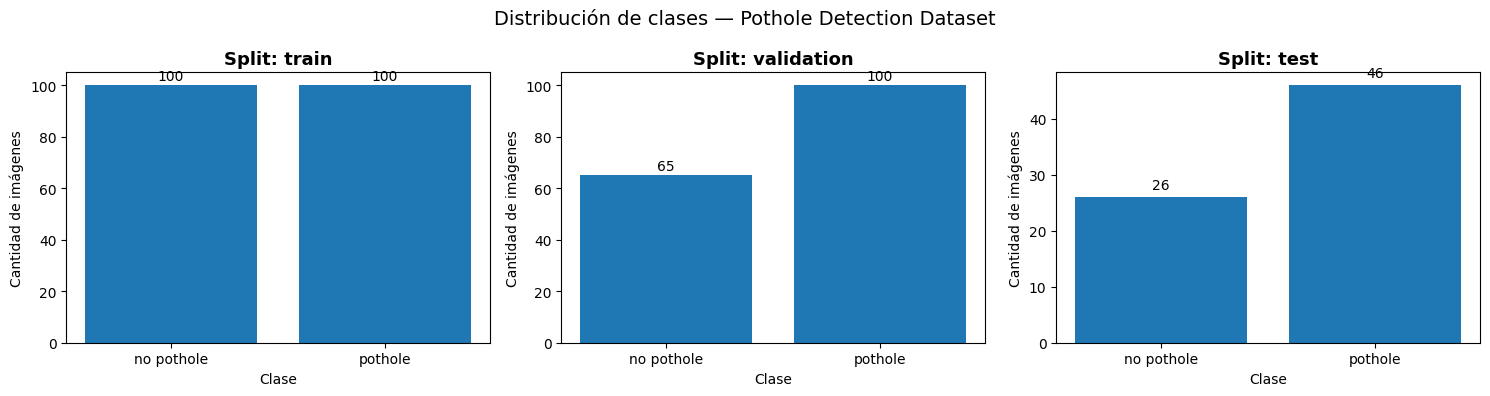

In [3]:

import os

os.makedirs("output", exist_ok=True)

plot_class_distribution(info, save_path="output/class_distribution.png")


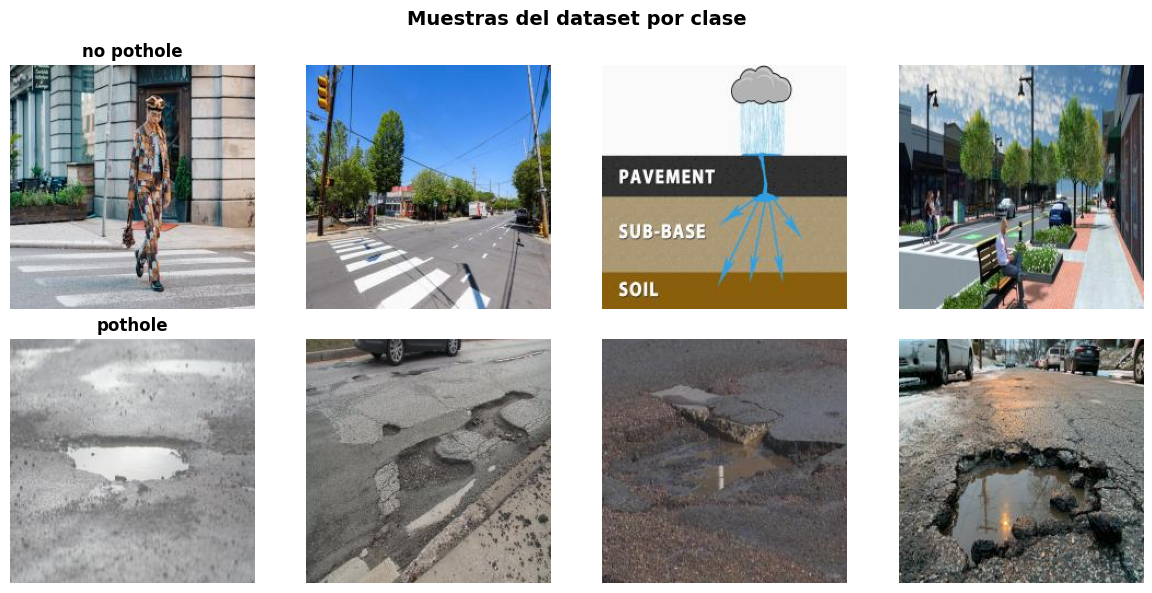

In [4]:
show_samples_by_class(info, split="train", samples_per_class=4, save_path="output/sample_images.png")


       width  height  channels
count  100.0   100.0     100.0
mean   224.0   224.0       3.0
std      0.0     0.0       0.0
min    224.0   224.0       3.0
25%    224.0   224.0       3.0
50%    224.0   224.0       3.0
75%    224.0   224.0       3.0
max    224.0   224.0       3.0


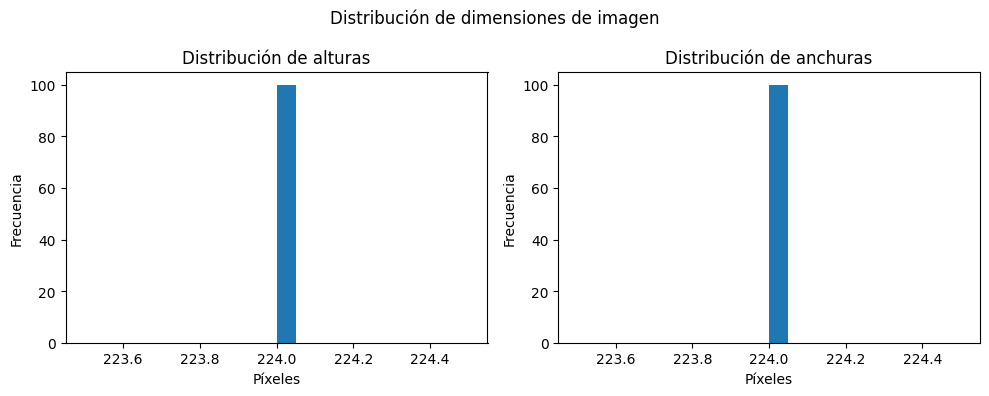

,width,height,channels
0,224,224,3
1,224,224,3
2,224,224,3
3,224,224,3
4,224,224,3


In [5]:
df_dims = image_dimension_report(info, split="train", n_samples=100, save_path="output/image_dimensions.png")
df_dims.head()


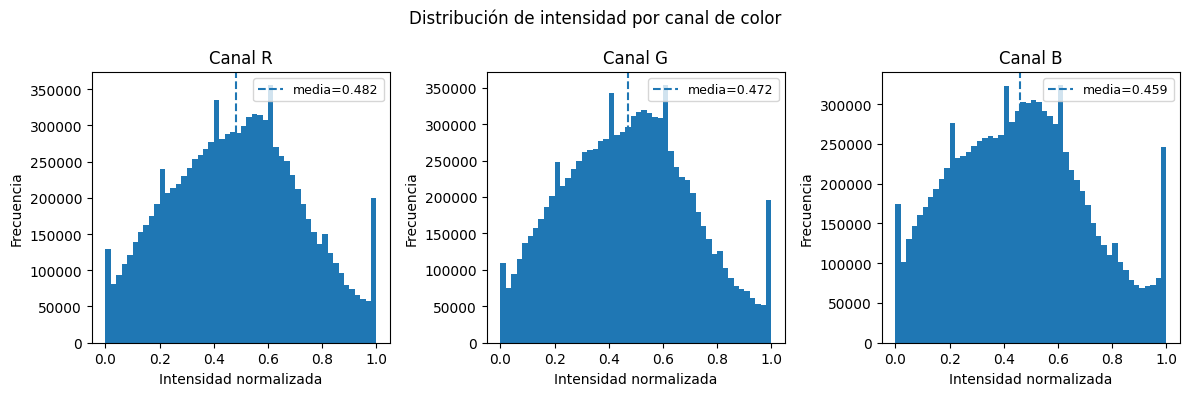

Estadísticas RGB:
Canal R: mean=0.4819, std=0.2368
Canal G: mean=0.4721, std=0.2333
Canal B: mean=0.4588, std=0.2457


{'R': {'mean': 0.48192736506462097, 'std': 0.23679234087467194},
 'G': {'mean': 0.4720512926578522, 'std': 0.23329317569732666},
 'B': {'mean': 0.45882174372673035, 'std': 0.24570640921592712}}

In [6]:
pixel_stats = pixel_statistics_report(info, split="train", n_samples=200, save_path="output/pixel_distribution.png")
pixel_stats


## 4. Preprocesamiento y DataLoaders

Se redimensionan las imágenes a `299 x 299`, tamaño esperado por InceptionV3, se aplica normalización de ImageNet y se usa data augmentation solo en entrenamiento.


In [7]:
IMAGE_SIZE = 299
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader, val_loader, test_loader, train_ds, val_ds, test_ds, info = create_dataloaders(
    dataset_name=DATASET_NAME,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

CLASS_NAMES = info.class_names
NUM_CLASSES = info.num_classes

print("Clases:", CLASS_NAMES)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Resolving data files:   0%|          | 0/200 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Clases: ['no pothole', 'pothole']
Train batches: 7
Validation batches: 6
Test batches: 3


## 4.1 Búsqueda controlada de hiperparámetros

Esta sección prueba varias configuraciones pequeñas antes del entrenamiento final. El objetivo es seleccionar valores razonables de `learning_rate`, `dropout`, `weight_decay` y `batch_size` usando **validación**, sin tocar el conjunto de test.

Para que sea viable en Colab, la búsqueda usa pocas épocas y un conjunto controlado de configuraciones. Si tienes más tiempo/GPU, puedes aumentar `EPOCHS_SEARCH` o agregar más combinaciones.

In [ ]:
import pandas as pd
import os

SEARCH_CSV = "output/hyperparameter_search_results.csv"

if os.path.exists(SEARCH_CSV):
    # Ya se ejecut? la b?squeda: cargar resultados del disco.
    results_df = pd.read_csv(SEARCH_CSV)
    results_df = results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
    print(f"Resultados cargados desde {SEARCH_CSV}")
else:
    # Primera ejecuci?n: correr la b?squeda completa.
    CONFIGS_SEARCH = [
        {"learning_rate": 1e-3, "dropout": 0.3, "weight_decay": 0.0,  "batch_size": 32},
        {"learning_rate": 1e-3, "dropout": 0.4, "weight_decay": 1e-4, "batch_size": 32},
        {"learning_rate": 5e-4, "dropout": 0.4, "weight_decay": 0.0,  "batch_size": 32},
        {"learning_rate": 5e-4, "dropout": 0.5, "weight_decay": 1e-4, "batch_size": 32},
        {"learning_rate": 1e-4, "dropout": 0.4, "weight_decay": 1e-4, "batch_size": 32},
        {"learning_rate": 1e-3, "dropout": 0.4, "weight_decay": 0.0,  "batch_size": 16},
        {"learning_rate": 5e-4, "dropout": 0.3, "weight_decay": 1e-4, "batch_size": 16},
        {"learning_rate": 1e-4, "dropout": 0.5, "weight_decay": 1e-4, "batch_size": 16},
    ]
    EPOCHS_SEARCH = 2
    results = []

    for i, cfg in enumerate(CONFIGS_SEARCH, start=1):
        lr, dropout = cfg["learning_rate"], cfg["dropout"]
        weight_decay, batch_size = cfg["weight_decay"], cfg["batch_size"]
        print(f"\nExperimento {i}/{len(CONFIGS_SEARCH)} | LR={lr} | Dropout={dropout} | WD={weight_decay} | BS={batch_size}")

        train_loader_exp, val_loader_exp, _, _, _, _, _ = create_dataloaders(
            dataset_name=DATASET_NAME, image_size=IMAGE_SIZE,
            batch_size=batch_size, num_workers=NUM_WORKERS,
        )
        model_exp = build_pothole_inception(num_classes=NUM_CLASSES, dropout=dropout, feature_extract=True).to(DEVICE)
        criterion_exp = nn.CrossEntropyLoss()
        optimizer_exp = optim.Adam(
            filter(lambda p: p.requires_grad, model_exp.parameters()),
            lr=lr, weight_decay=weight_decay,
        )
        train_losses_exp, val_losses_exp, train_accs_exp, val_accs_exp = train_model(
            model=model_exp, model_name=f"pothole_inception_search_exp_{i}",
            train_loader=train_loader_exp, val_loader=val_loader_exp,
            criterion=criterion_exp, optimizer=optimizer_exp,
            device=DEVICE, epochs=EPOCHS_SEARCH, save_dir="models/search",
        )
        results.append({
            "experiment": i, "learning_rate": lr, "dropout": dropout,
            "weight_decay": weight_decay, "batch_size": batch_size,
            "best_val_acc": max(val_accs_exp), "final_val_acc": val_accs_exp[-1],
            "final_train_acc": train_accs_exp[-1],
            "trainable_params": count_trainable_parameters(model_exp),
        })

    results_df = pd.DataFrame(results).sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)
    os.makedirs("output", exist_ok=True)
    results_df.to_csv(SEARCH_CSV, index=False)

results_df


## 4.2 Selección de mejores hiperparámetros

A partir de la búsqueda anterior, se toma la configuración con mayor `best_val_acc`. Estos valores se usarán en el entrenamiento final.

In [9]:
# =========================
# MEJORES HIPERPARÁMETROS
# =========================

best_config = results_df.iloc[0].to_dict()

BEST_LR = float(best_config["learning_rate"])
BEST_DROPOUT = float(best_config["dropout"])
BEST_WEIGHT_DECAY = float(best_config["weight_decay"])
BEST_BATCH_SIZE = int(best_config["batch_size"])

print("Mejores hiperparámetros:")
print(f"Learning rate: {BEST_LR}")
print(f"Dropout: {BEST_DROPOUT}")
print(f"Weight decay: {BEST_WEIGHT_DECAY}")
print(f"Batch size: {BEST_BATCH_SIZE}")

best_config

Mejores hiperparámetros:
Learning rate: 0.001
Dropout: 0.4
Weight decay: 0.0
Batch size: 16


{'experiment': 6.0,
 'learning_rate': 0.001,
 'dropout': 0.4,
 'weight_decay': 0.0,
 'batch_size': 16.0,
 'best_val_acc': 77.57575757575758,
 'final_val_acc': 77.57575757575758,
 'final_train_acc': 78.0,
 'trainable_params': 5636.0}

## 4.3 DataLoaders finales

Se reconstruyen los `DataLoaders` usando el mejor `batch_size` encontrado. Desde este punto, el entrenamiento final usa estos loaders.

In [10]:


train_loader, val_loader, test_loader, train_ds, val_ds, test_ds, info = create_dataloaders(
    dataset_name=DATASET_NAME,
    image_size=IMAGE_SIZE,
    batch_size=BEST_BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

CLASS_NAMES = info.class_names
NUM_CLASSES = info.num_classes

print("DataLoaders finales creados con batch size:", BEST_BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Resolving data files:   0%|          | 0/200 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

DataLoaders finales creados con batch size: 16
Train batches: 13
Validation batches: 11
Test batches: 5


## 5. Modelo CNN con Transfer Learning

Se usa InceptionV3 preentrenado en ImageNet. Primero se congelan las capas base y se entrena solo el clasificador final.


In [11]:
model = build_pothole_inception(
    num_classes=NUM_CLASSES,
    dropout=BEST_DROPOUT,
    feature_extract=True,
)
model = model.to(DEVICE)

print(model.__class__.__name__)
print("Dropout usado:", BEST_DROPOUT)
print("Parámetros entrenables:", count_trainable_parameters(model))

Inception3
Dropout usado: 0.4
Parámetros entrenables: 5636


## 6. Fase 1 — Feature Extraction

In [ ]:
os.makedirs("models", exist_ok=True)
os.makedirs("output", exist_ok=True)

EPOCHS_PHASE1 = 15
LR_PHASE1 = BEST_LR

from sklearn.utils.class_weight import compute_class_weight

# Acceso directo al dataset HF sin aplicar transforms (mucho m?s r?pido)
raw_labels = train_ds.data[train_ds.label_key]
if train_ds._string_labels:
    train_labels = [train_ds._label_map[l] for l in raw_labels]
else:
    train_labels = [int(l) for l in raw_labels]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=np.array(train_labels),
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f"Class weights: {class_weights_tensor}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
    weight_decay=BEST_WEIGHT_DECAY,
)

scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

print("=== FASE 1: Feature Extraction ===")
print(f"LR fase 1: {LR_PHASE1}")
print(f"Weight decay: {BEST_WEIGHT_DECAY}")

train_losses_p1, val_losses_p1, train_accs_p1, val_accs_p1 = train_model(
    model=model,
    model_name="pothole_inception_phase1",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS_PHASE1,
    patience=5,
    scheduler=scheduler_p1,
)


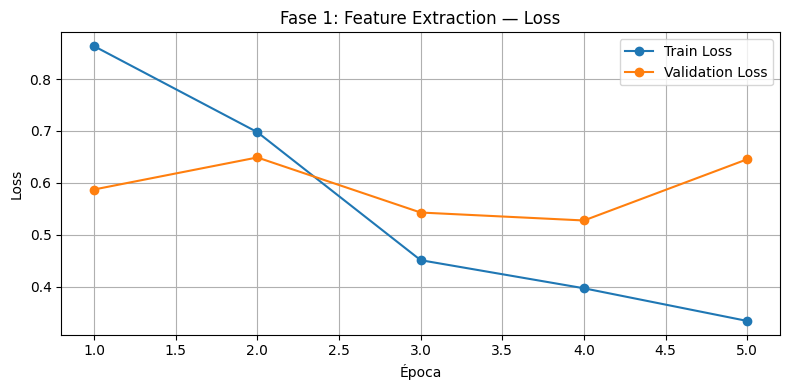

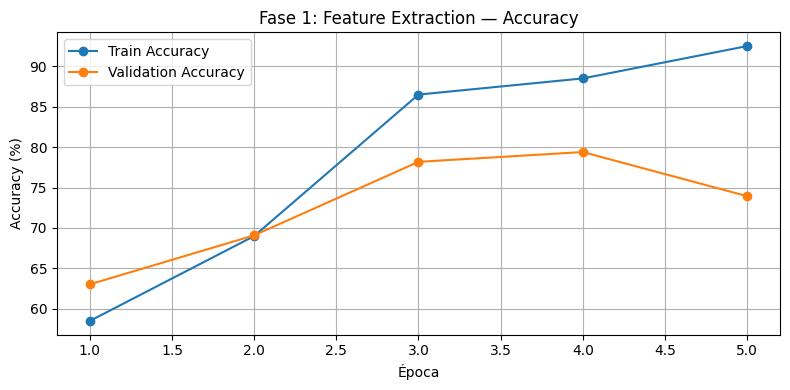

In [13]:
plot_training_curves(
    train_losses_p1, val_losses_p1,
    train_accs_p1, val_accs_p1,
    title="Fase 1: Feature Extraction",
    save_path="output/curves_phase1.png",
)


## 7. Fase 2 — Fine-tuning

Se descongelan de forma explícita los bloques finales `Mixed_7b` y `Mixed_7c` de InceptionV3, además del clasificador principal. Esto es más claro que descongelar “los últimos 40 parámetros”, porque permite justificar exactamente qué parte del modelo se está ajustando.

En esta fase se usa un learning rate menor que en Feature Extraction para no modificar agresivamente los pesos preentrenados.

In [ ]:
# =========================
# FASE 2 ? FINE-TUNING EXPL?CITO POR BLOQUES
# =========================

# Congelar todo el modelo primero.
for param in model.parameters():
    param.requires_grad = False

# Descongelar bloques profundos + clasificador usando la funci?n del m?dulo.
BLOCKS_TO_UNFREEZE = ("Mixed_7b", "Mixed_7c")
model = unfreeze_last_layers(model, list(BLOCKS_TO_UNFREEZE))

print("Bloques descongelados para fine-tuning:", BLOCKS_TO_UNFREEZE)
print("Par?metros entrenables despu?s de fine-tuning:", count_trainable_parameters(model))

EPOCHS_PHASE2 = 12
LR_PHASE2 = max(BEST_LR / 10, 1e-5)

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2,
    weight_decay=BEST_WEIGHT_DECAY,
)

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=EPOCHS_PHASE2, eta_min=1e-6
)

print("=== FASE 2: Fine-tuning ===")
print(f"LR fase 2: {LR_PHASE2}")

train_losses_p2, val_losses_p2, train_accs_p2, val_accs_p2 = train_model(
    model=model,
    model_name="pothole_inception_finetune",
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    device=DEVICE,
    epochs=EPOCHS_PHASE2,
    patience=5,
    scheduler=scheduler_p2,
)


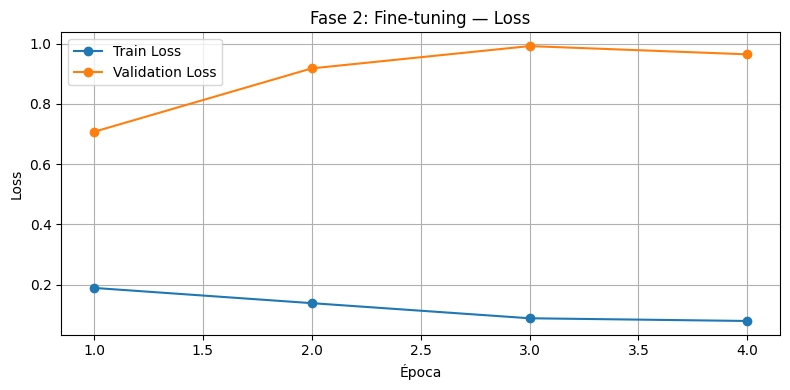

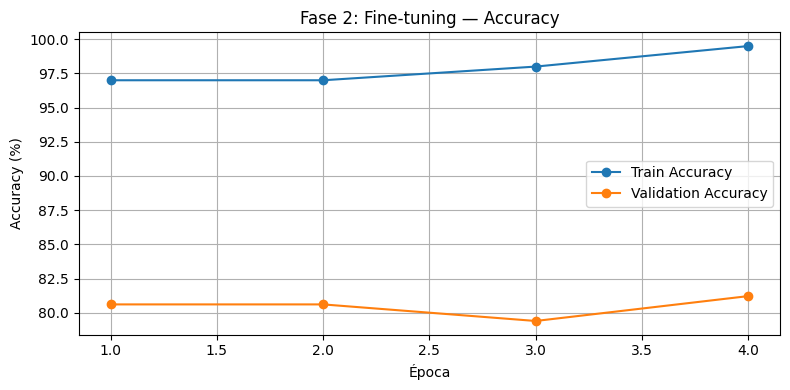

In [15]:
plot_training_curves(
    train_losses_p2, val_losses_p2,
    train_accs_p2, val_accs_p2,
    title="Fase 2: Fine-tuning",
    save_path="output/curves_phase2.png",
)


## 8. Evaluación final

Se calculan métricas por clase, matriz de confusión y ejemplos visuales de predicciones.


In [16]:
metrics = classification_metrics(model, test_loader, DEVICE, class_names=CLASS_NAMES)

print(f"Accuracy:           {metrics['accuracy']:.2f}%")
print(f"Precision weighted: {metrics['precision_weighted']:.4f}")
print(f"Recall weighted:    {metrics['recall_weighted']:.4f}")
print(f"F1 weighted:        {metrics['f1_weighted']:.4f}")
print(f"F1 macro:           {metrics['f1_macro']:.4f}")
print(f"Recall macro:       {metrics['recall_macro']:.4f}")
print("\nClassification report:")
print(metrics["classification_report"])


Predicting:   0%|          | 0/5 [00:11<?, ?it/s]

Accuracy:           75.00%
Precision weighted: 0.8325
Recall weighted:    0.7500
F1 weighted:        0.7531
F1 macro:           0.7492
Recall macro:       0.7960

Classification report:
              precision    recall  f1-score   support

  no pothole       0.60      0.96      0.74        26
     pothole       0.97      0.63      0.76        46

    accuracy                           0.75        72
   macro avg       0.78      0.80      0.75        72
weighted avg       0.83      0.75      0.75        72



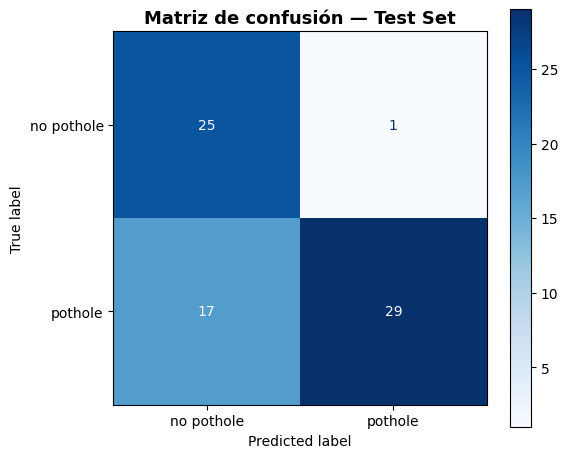

In [17]:
plot_confusion_matrix(
    metrics["confusion_matrix"],
    CLASS_NAMES,
    save_path="output/confusion_matrix.png",
)


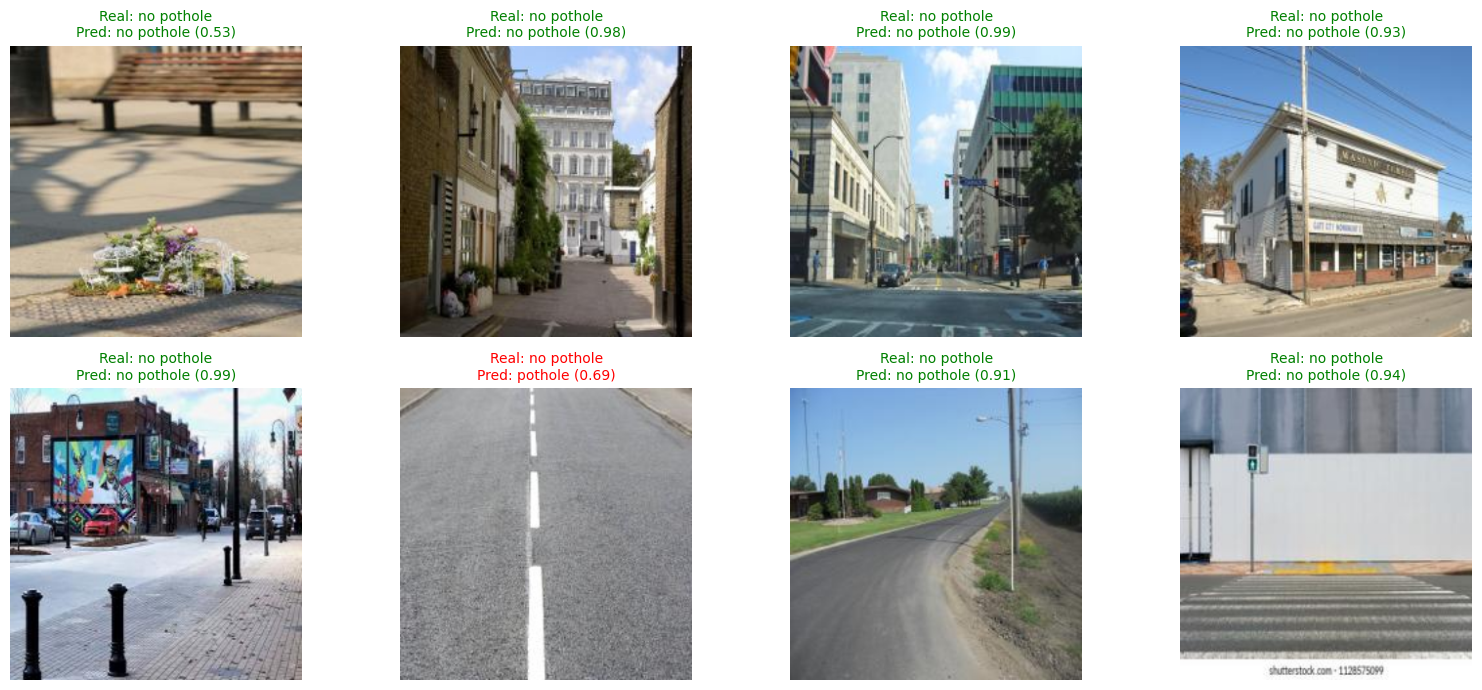

In [18]:
show_predictions(
    model=model,
    dataloader=test_loader,
    device=DEVICE,
    class_names=CLASS_NAMES,
    n=8,
    save_path="output/predictions.png",
)


Matriz de confusión absoluta:
[[25  1]
 [17 29]]

Matriz de confusión normalizada:
[[0.96153846 0.03846154]
 [0.36956522 0.63043478]]


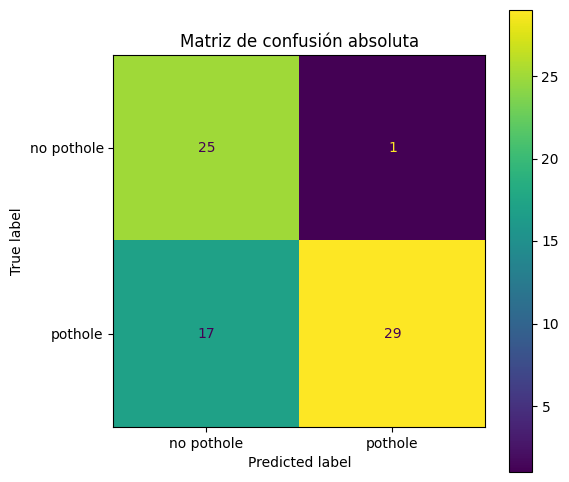

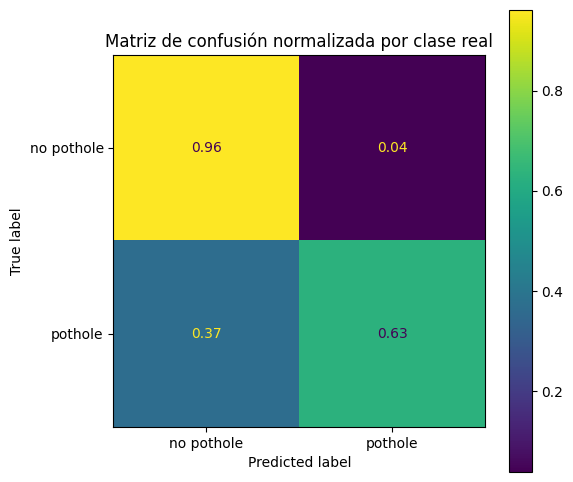

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_names = ["no pothole", "pothole"]
# Extraer etiquetas reales y predicciones
y_true = metrics["y_true"]
y_pred = metrics["y_pred"]

# Matriz de confusión absoluta
cm_abs = confusion_matrix(y_true, y_pred)

# Matriz de confusión normalizada por fila
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

print("Matriz de confusión absoluta:")
print(cm_abs)

print("\nMatriz de confusión normalizada:")
print(cm_norm)

# Visualización matriz absoluta
fig, ax = plt.subplots(figsize=(6, 6))
disp_abs = ConfusionMatrixDisplay(
    confusion_matrix=cm_abs,
    display_labels=class_names
)
disp_abs.plot(ax=ax, values_format="d")
plt.title("Matriz de confusión absoluta")
plt.show()

# Visualización matriz normalizada
fig, ax = plt.subplots(figsize=(6, 6))
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp_norm.plot(ax=ax, values_format=".2f")
plt.title("Matriz de confusión normalizada por clase real")
plt.show()

In [20]:
# Detectar índice de la clase pothole
pothole_idx = None

for i, name in enumerate(class_names):
    if str(name).lower() == "pothole":
        pothole_idx = i
        break

if pothole_idx is None:
    raise ValueError("No se encontró la clase 'pothole' en class_names.")

print("Índice de clase pothole:", pothole_idx)

Índice de clase pothole: 1


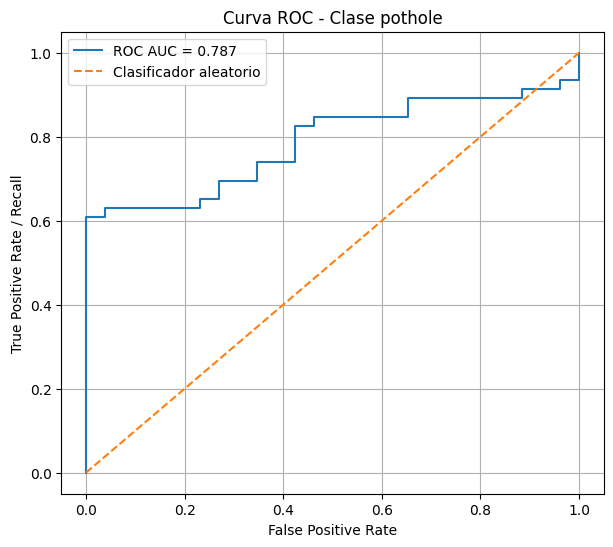

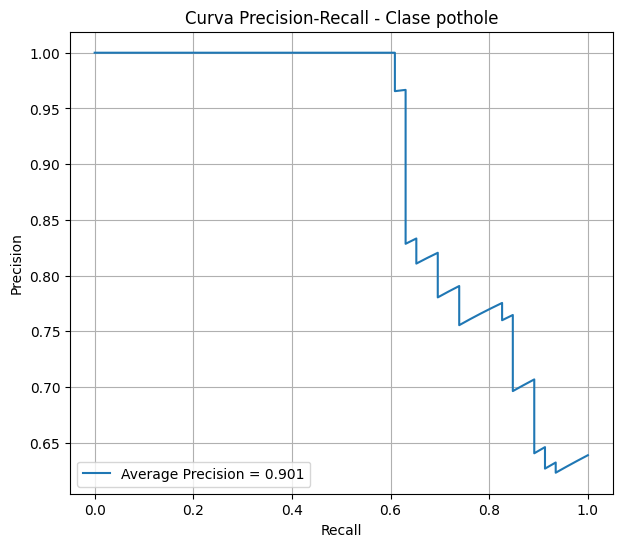

ROC AUC: 0.7868
Average Precision: 0.9008


In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Etiquetas reales
y_true = np.array(metrics["y_true"])

# Probabilidades predichas
y_prob = np.array(metrics["y_prob"])

# Convertir y_true a binario: 1 = pothole, 0 = no pothole
y_true_bin = (y_true == pothole_idx).astype(int)

# Probabilidad asignada a la clase pothole
y_score_pothole = y_prob[:, pothole_idx]

# =========================
# Curva ROC
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_true_bin, y_score_pothole)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curva ROC - Clase pothole")
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Curva Precision-Recall
# =========================
precision, recall, pr_thresholds = precision_recall_curve(
    y_true_bin,
    y_score_pothole
)

avg_precision = average_precision_score(
    y_true_bin,
    y_score_pothole
)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Clase pothole")
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")

In [22]:
# Analisis de umbral óptimo usando F1-score

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    # Si probabilidad de pothole >= threshold, predecir pothole
    y_pred_threshold = np.where(
        y_score_pothole >= threshold,
        pothole_idx,
        1 - pothole_idx
    )

    precision_t = precision_score(
        y_true,
        y_pred_threshold,
        pos_label=pothole_idx,
        zero_division=0
    )

    recall_t = recall_score(
        y_true,
        y_pred_threshold,
        pos_label=pothole_idx,
        zero_division=0
    )

    f1_t = f1_score(
        y_true,
        y_pred_threshold,
        pos_label=pothole_idx,
        zero_division=0
    )

    acc_t = accuracy_score(y_true, y_pred_threshold)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": acc_t,
        "precision_pothole": precision_t,
        "recall_pothole": recall_t,
        "f1_pothole": f1_t
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,accuracy,precision_pothole,recall_pothole,f1_pothole
0,0.10,0.722222,0.906250,0.630435,0.743590
1,0.15,0.722222,0.906250,0.630435,0.743590
2,0.20,0.722222,0.906250,0.630435,0.743590
3,0.25,0.722222,0.906250,0.630435,0.743590
4,0.30,0.722222,0.906250,0.630435,0.743590
5,0.35,0.736111,0.935484,0.630435,0.753247
6,0.40,0.736111,0.935484,0.630435,0.753247
7,0.45,0.736111,0.935484,0.630435,0.753247
8,0.50,0.750000,0.966667,0.630435,0.763158
9,0.55,0.750000,0.966667,0.630435,0.763158


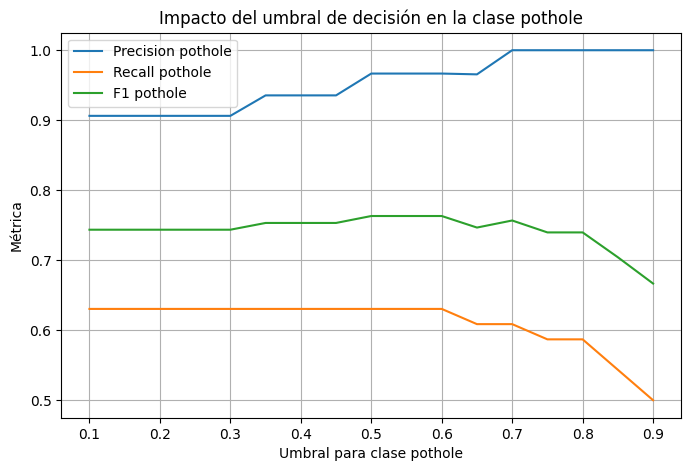

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision_pothole"], label="Precision pothole")
plt.plot(threshold_df["threshold"], threshold_df["recall_pothole"], label="Recall pothole")
plt.plot(threshold_df["threshold"], threshold_df["f1_pothole"], label="F1 pothole")
plt.xlabel("Umbral para clase pothole")
plt.ylabel("Métrica")
plt.title("Impacto del umbral de decisión en la clase pothole")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================
# APLICAR THRESHOLD ?PTIMO
# Busca el threshold donde recall_pothole >= 0.80
# con el mayor F1 posible (?ltimo punto que cumple recall >= 0.80)
# =========================

candidates = threshold_df[threshold_df["recall_pothole"] >= 0.80]

if len(candidates) == 0:
    print("No hay threshold con recall_pothole >= 0.80. Usando el de mayor recall.")
    optimal_row = threshold_df.loc[threshold_df["recall_pothole"].idxmax()]
else:
    # Entre todos los que cumplen recall >= 0.80, tomamos el de mayor F1
    optimal_row = candidates.loc[candidates["f1_pothole"].idxmax()]

OPTIMAL_THRESHOLD = float(optimal_row["threshold"])
print(f"Threshold ?ptimo:  {OPTIMAL_THRESHOLD:.2f}")
print(f"Precision pothole: {optimal_row['precision_pothole']:.3f}")
print(f"Recall pothole:    {optimal_row['recall_pothole']:.3f}")
print(f"F1 pothole:        {optimal_row['f1_pothole']:.3f}")
print(f"Accuracy:          {optimal_row['accuracy']:.3f}")

# Reevaluar con threshold ?ptimo
y_pred_opt = np.where(
    y_score_pothole >= OPTIMAL_THRESHOLD,
    pothole_idx,
    1 - pothole_idx,
)

print("\nClassification report con threshold ?ptimo:")
from sklearn.metrics import classification_report as _cr
print(_cr(y_true, y_pred_opt, target_names=CLASS_NAMES))


## 8.1 Análisis de errores

Además de las métricas globales, se revisan las imágenes mal clasificadas. Esto ayuda a identificar patrones de error como sombras confundidas con huecos, huecos pequeños, baja iluminación o pavimento deteriorado.

In [24]:
# =========================
# TABLA DE ERRORES EN TEST
# =========================

from collections import Counter

# Asegurar que pandas esté disponible aunque se ejecute esta sección de forma independiente.
import pandas as pd

y_true = metrics["y_true"]
y_pred = metrics["y_pred"]
y_prob = metrics["y_prob"]

error_indices = np.where(y_true != y_pred)[0]

errors_df = pd.DataFrame({
    "dataset_index": error_indices,
    "true_label": [CLASS_NAMES[y_true[i]] for i in error_indices],
    "pred_label": [CLASS_NAMES[y_pred[i]] for i in error_indices],
    "confidence": [float(np.max(y_prob[i])) for i in error_indices],
    "prob_true_class": [float(y_prob[i][y_true[i]]) for i in error_indices],
    "prob_pred_class": [float(y_prob[i][y_pred[i]]) for i in error_indices],
}).sort_values(by="confidence", ascending=False)

error_types = [f"{CLASS_NAMES[y_true[i]]} → {CLASS_NAMES[y_pred[i]]}" for i in error_indices]
error_summary_df = pd.DataFrame({
    "tipo_error": list(Counter(error_types).keys()),
    "cantidad": list(Counter(error_types).values()),
}).sort_values(by="cantidad", ascending=False)

print(f"Total de errores en test: {len(errors_df)}")
display(error_summary_df)
errors_df.head(10)

Total de errores en test: 18


,tipo_error,cantidad
1,pothole → no pothole,17
0,no pothole → pothole,1


,dataset_index,true_label,pred_label,confidence,prob_true_class,prob_pred_class
5,46,pothole,no pothole,0.998267,0.001733,0.998267
11,53,pothole,no pothole,0.996505,0.003495,0.996505
12,54,pothole,no pothole,0.995816,0.004184,0.995816
2,43,pothole,no pothole,0.994838,0.005162,0.994838
14,57,pothole,no pothole,0.991444,0.008556,0.991444
10,51,pothole,no pothole,0.984918,0.015082,0.984918
17,62,pothole,no pothole,0.981833,0.018167,0.981833
15,58,pothole,no pothole,0.976462,0.023538,0.976462
4,45,pothole,no pothole,0.973167,0.026833,0.973167
13,56,pothole,no pothole,0.972991,0.027009,0.972991


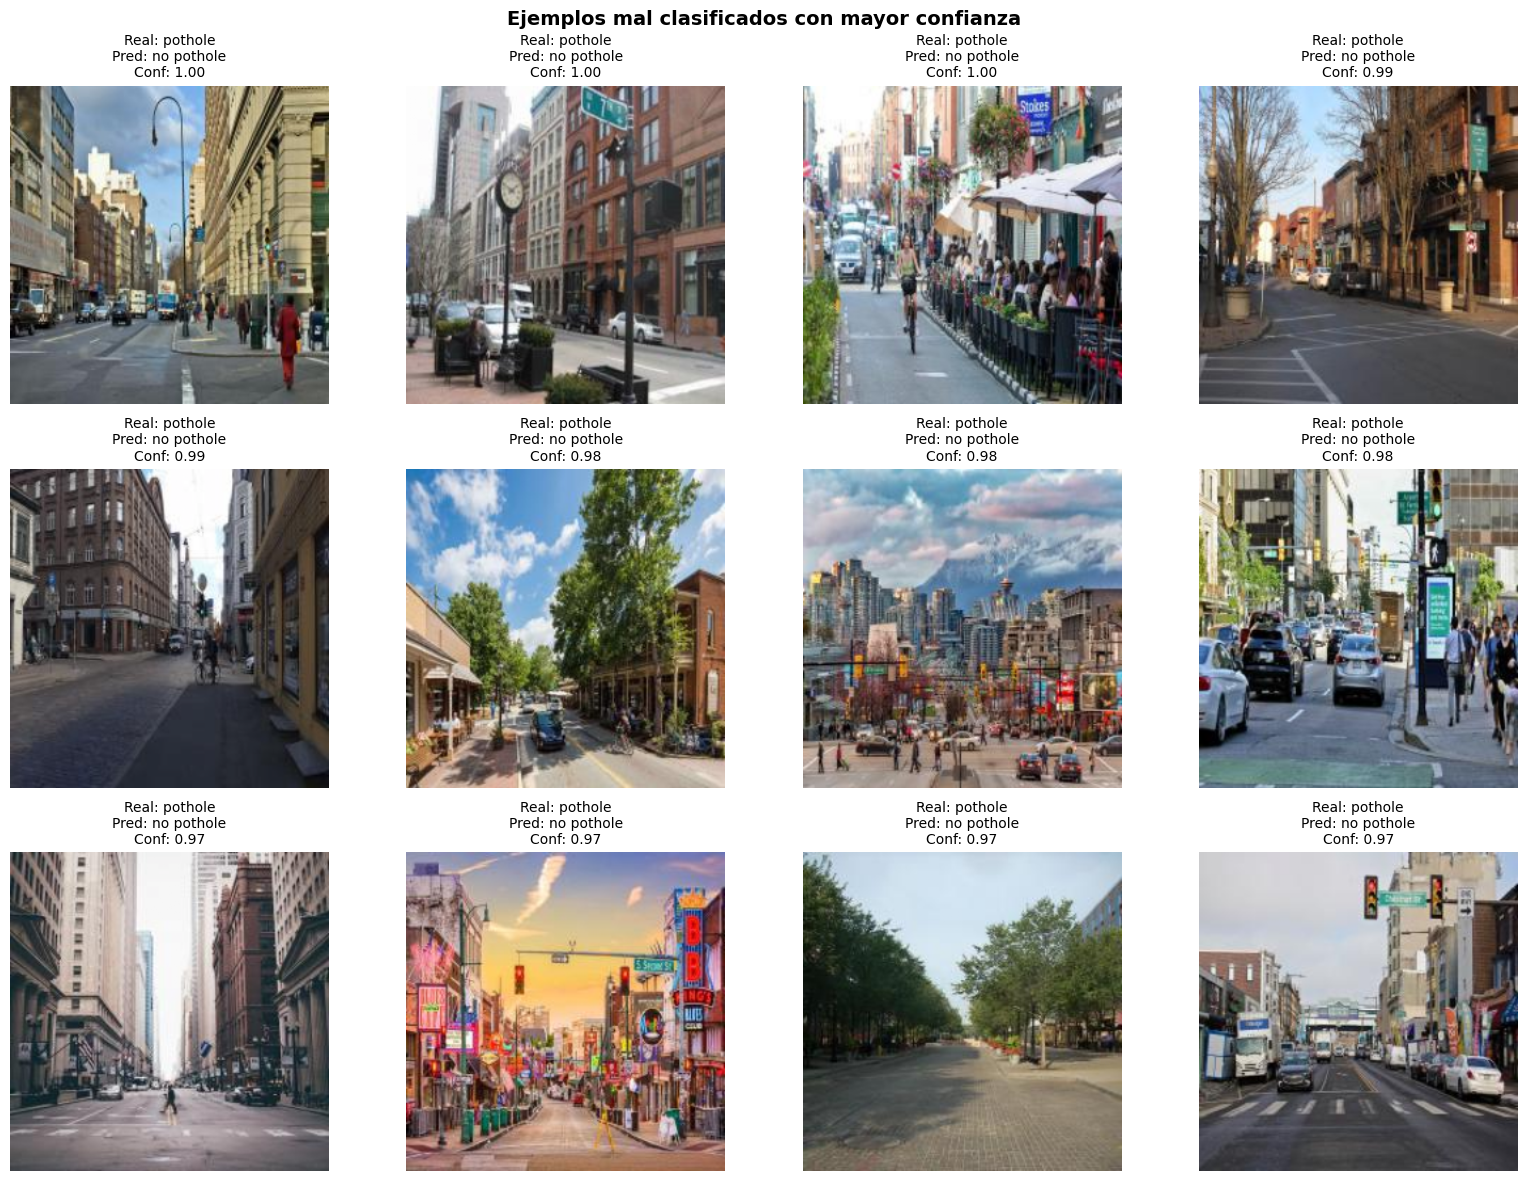

In [25]:
# =========================
# VISUALIZACIÓN DE IMÁGENES MAL CLASIFICADAS
# =========================

from src.utils import unnormalize


def show_misclassified_examples(test_ds, metrics, class_names, n=12, save_path="output/misclassified_examples.png"):
    y_true = metrics["y_true"]
    y_pred = metrics["y_pred"]
    y_prob = metrics["y_prob"]

    error_indices = np.where(y_true != y_pred)[0]

    if len(error_indices) == 0:
        print("No hay errores para mostrar.")
        return

    sorted_errors = sorted(
        error_indices,
        key=lambda i: np.max(y_prob[i]),
        reverse=True,
    )

    selected = sorted_errors[:n]
    cols = min(4, len(selected))
    rows = int(np.ceil(len(selected) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, selected):
        image, _ = test_ds[idx]
        image_np = unnormalize(image)

        true_name = class_names[y_true[idx]]
        pred_name = class_names[y_pred[idx]]
        conf = np.max(y_prob[idx])

        ax.imshow(image_np)
        ax.set_title(
            f"Real: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}",
            fontsize=10,
        )
        ax.axis("off")

    plt.suptitle("Ejemplos mal clasificados con mayor confianza", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=140)
    plt.show()


show_misclassified_examples(
    test_ds=test_ds,
    metrics=metrics,
    class_names=CLASS_NAMES,
    n=12,
)

## 9. Grad-CAM — Explicabilidad

Grad-CAM ayuda a revisar si el modelo está mirando la zona del hueco o si se está guiando por señales espurias como sombras, bordes o textura del pavimento.


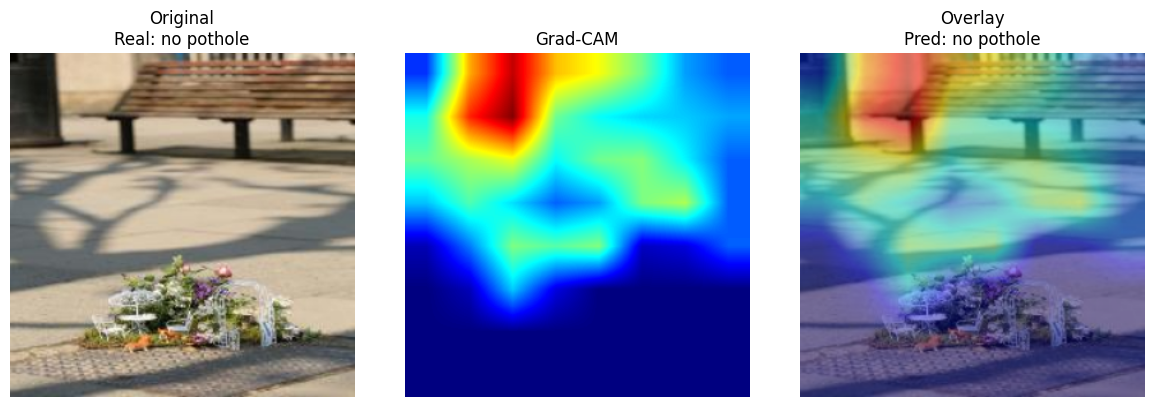

In [26]:
# Grad-CAM con una imagen del test set
# Para InceptionV3, una capa profunda útil es Mixed_7c.

model.eval()
if hasattr(model, "aux_logits"):
    model.aux_logits = False

images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(DEVICE)
image.requires_grad_(True)
true_label = int(labels[0])

capture, remove = attach_hooks(model, "Mixed_7c")
output, pred = run_forward(model, image)
run_backward(output, pred)
cam = compute_gradcam(capture["act"], capture["grad"])
cam = resize_cam(cam, images[0].shape[1], images[0].shape[2])
remove()

# Reconstrucción visual de la imagen normalizada
from src.utils import unnormalize
orig = unnormalize(images[0])
orig_uint8 = (orig * 255).astype(np.uint8)
cam_np = cam.detach().cpu().numpy()
overlay, heatmap = overlay_cam(orig_uint8, cam_np)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(orig_uint8)
axes[0].set_title(f"Original\nReal: {CLASS_NAMES[true_label]}")
axes[0].axis("off")

axes[1].imshow(heatmap)
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Overlay\nPred: {CLASS_NAMES[pred]}")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("output/gradcam_example.png", bbox_inches="tight", dpi=140)
plt.show()

## 10. Resumen para el proyecto

Este pipeline cumple con los componentes principales del proyecto:

- selección y justificación de una base de datos de imágenes;
- EDA con visualizaciones;
- preprocesamiento y aumento de datos;
- implementación de una CNN con transfer learning;
- entrenamiento en dos fases;
- evaluación con múltiples métricas;
- explicabilidad mediante Grad-CAM;
- resultados visuales para usar en la presentación.
